# Prosit IA — Données Immobilières Californiennes
## Agence Loft's Craft

Ce notebook sert de réponse à la problématique posée par le prosit 1. Dans celui-ci, il est question d'une agence qui souhaite utiliser l'IA pour réduire le nombre de visites inutiles. Pour ce faire, nous importerons ses données depuis 1990, les nettoierons puis utiliserons l'algorithme K-Means avec le meilleur hyperparamètre pour l'étude. 

Voici donc le plan d'action :
1. Imports & Configuration
2. Chargement des données
3. Exploration des données
4. Gestion des valeurs manquantes
5. Visualisation Exploratoire
6. Normalisation
7. Méthode du Coude
8. Méthode de la Silhouette
9. Algorithme K-Means

## 1. Imports & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')


print('Bibliothèques chargées avec succès !')

Bibliothèques chargées avec succès !


## 2. Chargement des données

Le dataset complet est disponible dans le fichier `housing.csv`.

In [2]:
df = pd.read_csv('housing.csv')

print(f'Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes')
df.head()

Dataset chargé : 20640 lignes, 10 colonnes


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Exploration des données

In [3]:
# Informations générales
print('=== INFO ===')
df.info()
print()
print('=== STATISTIQUES DESCRIPTIVES ===')
df.describe().round(2)

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

=== STATISTIQUES DESCRIPTIVES ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


In [4]:
# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquantes': missing, '% du total': missing_pct})
print('=== VALEURS MANQUANTES ===')
print(missing_df[missing_df['Manquantes'] > 0])
if missing.sum() == 0:
    print('Aucune valeur manquante détectée (sklearn supprime les NaN).')
    print('Note : le CSV original a ~207 NaN dans total_bedrooms.')

=== VALEURS MANQUANTES ===
                Manquantes  % du total
total_bedrooms         207         1.0


## 4. Gestion des valeurs manquantes

Pour les colonnes numériques, on va remplacer par la **médiane**.
Pour les colonnes catégorielles, on va remplacer par le **mode**.

In [5]:
# Imputation des valeurs manquantes
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Numériques -> médiane
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        print(f'{col} : {df[col].isnull().sum()} NaN imputés par médiane = {median_val:.2f}')
        df[col] = df[col].fillna(median_val, inplace=True)

# Catégorielles -> mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        print(f'{col} : NaN imputés par mode = {mode_val}')
        df[col] = df[col].fillna(mode_val, inplace=True)

print(f'\nValeurs manquantes restantes : {df.isnull().sum().sum()}')

total_bedrooms : 207 NaN imputés par médiane = 435.00

Valeurs manquantes restantes : 0


## 5. Visualisation exploratoire

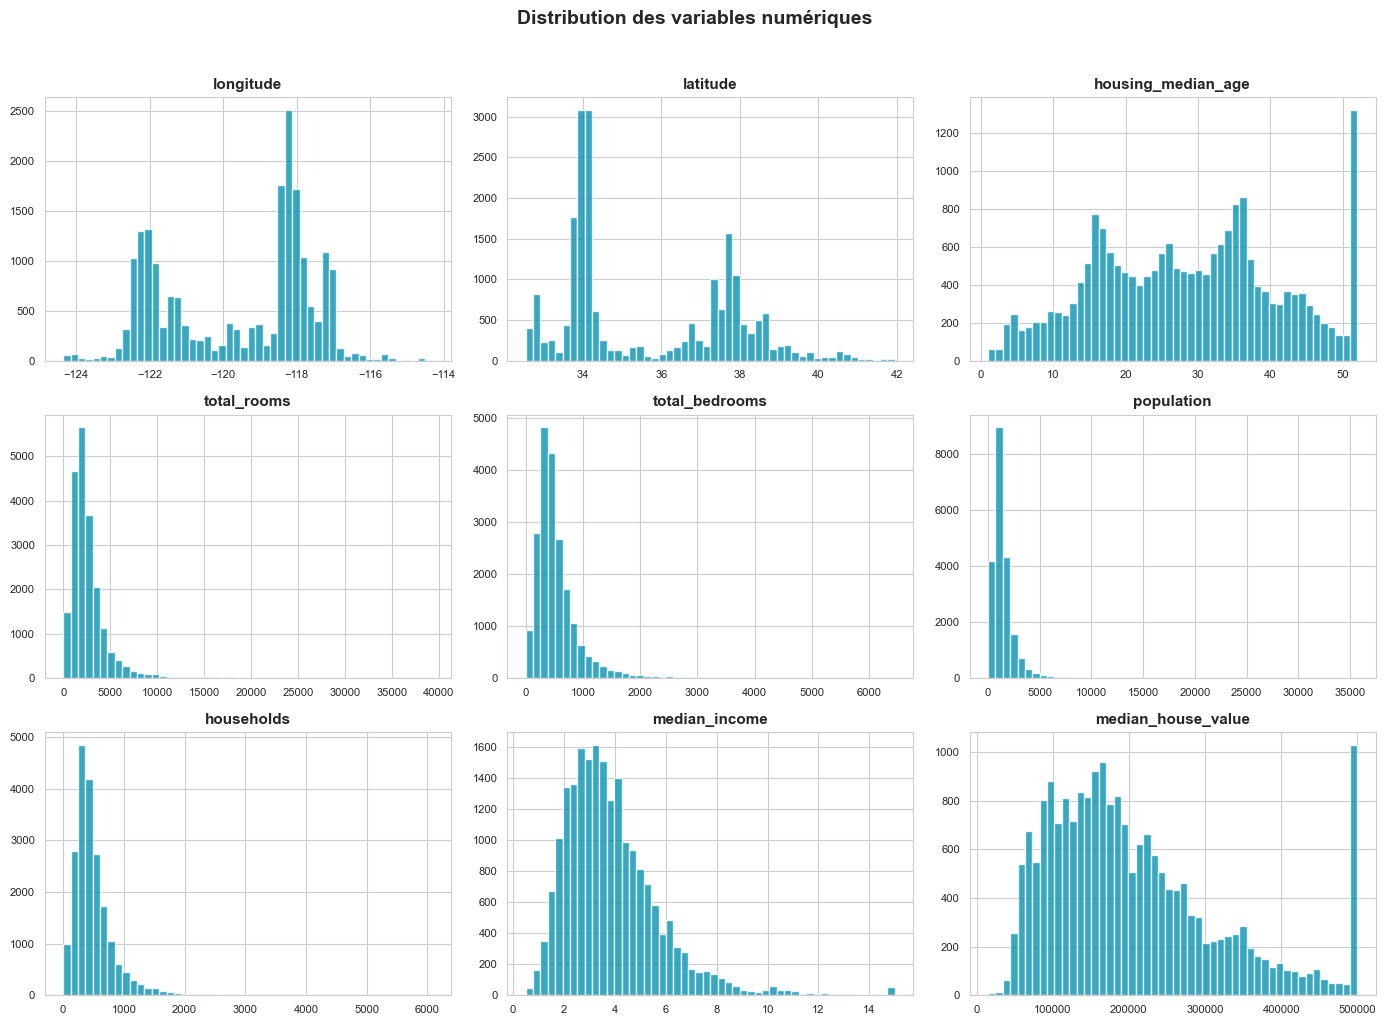

In [6]:
# Histogrammes de toutes les variables numériques
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, col in enumerate(numeric_cols[:9]):
    ax = axes[i // 3, i % 3]
    df[col].hist(bins=50, ax=ax, color='#0891B2', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=8)
plt.suptitle('Distribution des variables numériques', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

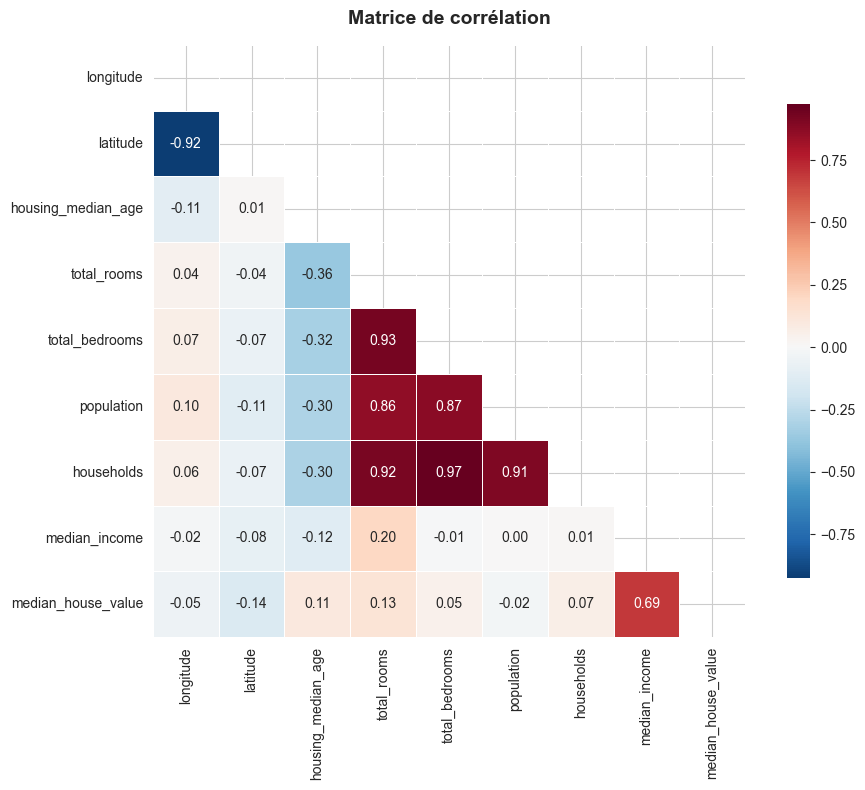

In [7]:
# Matrice de corrélation
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

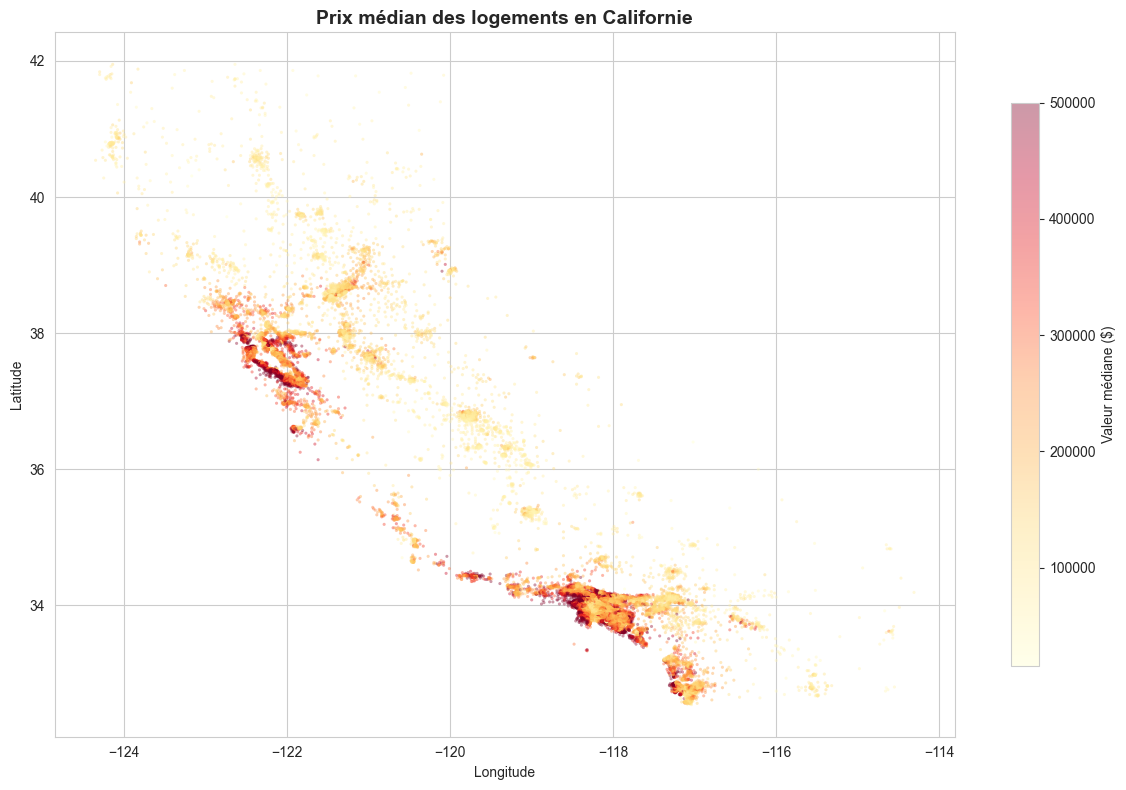

In [8]:
# Carte géographique : prix médian des logements
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    df['longitude'], df['latitude'],
    c=df['median_house_value'],
    cmap='YlOrRd', alpha=0.4, s=5,
    edgecolors='none'
)
plt.colorbar(scatter, label='Valeur médiane ($)', shrink=0.8)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Prix médian des logements en Californie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Normalisation

L'algorithme K-Means est sensible à l'échelle des variables, il est donc nécessaire de les normaliser pour pouvoir utiliser cet algorithme efficacement.

In [9]:
# On sélection des features pour le clustering
features_for_clustering = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Features utilisées ({len(features_for_clustering)}) :')
print(features_for_clustering)

# On définit un nouveau DataFrame sur lequel travailler
X = df[features_for_clustering].copy()

# On normalise les données numériques pour que le clustering ne soit pas biaisé par les échelles différentes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('=== VISUALISATION DES DONNÉES D\'ENTRAÎNEMENT ===')
print(X_scaled)

Features utilisées (9) :
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
=== VISUALISATION DES DONNÉES D'ENTRAÎNEMENT ===
[[-1.32783522  1.05254828  0.98214266 ... -0.97703285  2.34476576
   2.12963148]
 [-1.32284391  1.04318455 -0.60701891 ...  1.66996103  2.33223796
   1.31415614]
 [-1.33282653  1.03850269  1.85618152 ... -0.84363692  1.7826994
   1.25869341]
 ...
 [-0.8237132   1.77823747 -0.92485123 ... -0.17404163 -1.14259331
  -0.99274649]
 [-0.87362627  1.77823747 -0.84539315 ... -0.39375258 -1.05458292
  -1.05860847]
 [-0.83369581  1.75014627 -1.00430931 ...  0.07967221 -0.78012947
  -1.01787803]]


## 7. Méthode du Coude

On cherche le nombre optimal de clusters en traçant l'inertie pour k = 2 à 20. On cherche visuellement le k qui sert de point d'inflexion de la courbe tracée.

k =  1 | Inertie = 185,760
k =  2 | Inertie = 141,998
k =  3 | Inertie = 110,044
k =  4 | Inertie = 94,942
k =  5 | Inertie = 82,684
k =  6 | Inertie = 76,294
k =  7 | Inertie = 70,132
k =  8 | Inertie = 65,221
k =  9 | Inertie = 61,474
k = 10 | Inertie = 58,174
k = 11 | Inertie = 55,336
k = 12 | Inertie = 53,246
k = 13 | Inertie = 51,248
k = 14 | Inertie = 49,507
k = 15 | Inertie = 47,779
k = 16 | Inertie = 46,239
k = 17 | Inertie = 44,736
k = 18 | Inertie = 43,434
k = 19 | Inertie = 42,357
k = 20 | Inertie = 41,220


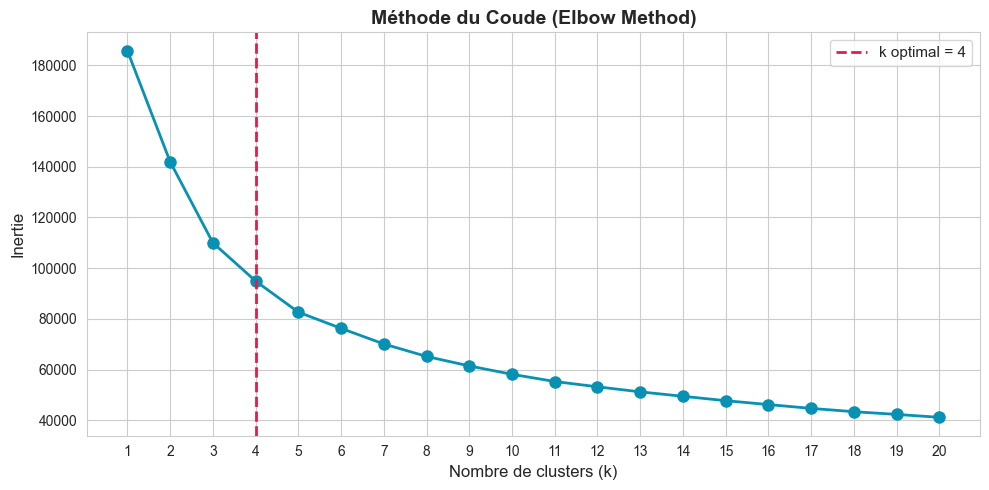


Point d'inflexion détecté à k = 4


In [10]:
# Méthode du coude
inertias = []
K_range = range(1, 21)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f'k = {k:2d} | Inertie = {kmeans.inertia_:,.0f}')

# En appliquant la dérivée seconde, on peut déterminer le point d'inflexion et donc les k les plus optimales
inertias_arr = np.array(inertias)
deltas       = np.diff(inertias_arr)
curvatures   = np.diff(deltas)
optimal_idx  = np.argmax(curvatures) + 2
optimal_k    = list(K_range)[optimal_idx]

# Graphique
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, inertias, 'o-', color='#0891B2', linewidth=2, markersize=8)
ax.axvline(x=optimal_k, color='#E11D48', linestyle='--', linewidth=2, label=f'k optimal = {optimal_k}')
ax.set_xlabel('Nombre de clusters (k)', fontsize=12)
ax.set_ylabel('Inertie', fontsize=12)
ax.set_title('Méthode du Coude (Elbow Method)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

print(f'\nPoint d\'inflexion détecté à k = {optimal_k}')

# 8. Méthode de la Silhouette

On va également déterminer les distances de chaque point entre eux dans un même cluster et leur distance par rapport aux centroïdes des autres clusters pour ensuite en calculer la moyenne et chercher la valeur maximale. Celle-ci déterminera quel hyperparamètre k est le plus adapté.

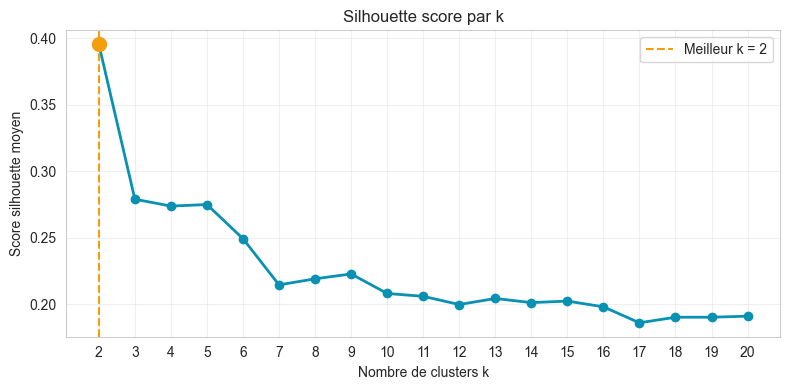


Meilleur k : 2


In [11]:
silhouette_scores = {}

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    silhouette_scores[k] = score

best_k = max(silhouette_scores, key=silhouette_scores.get)

# On dessine la courbe associée
ks = list(silhouette_scores.keys())
scores = list(silhouette_scores.values())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, scores, marker='o', linewidth=2, color='#0891B2', markersize=6)
ax.axvline(x=best_k, color='#F59E0B', linestyle='--', linewidth=1.5, label=f'Meilleur k = {best_k}')
ax.scatter([best_k], [silhouette_scores[best_k]], color='#F59E0B', s=100, zorder=5)
ax.set_xlabel('Nombre de clusters k')
ax.set_ylabel('Score silhouette moyen')
ax.set_title('Silhouette score par k')
ax.set_xticks(ks)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nMeilleur k : {best_k}')

## 9. Algorithme K-Means

In [12]:
# On entraîne avec les deux résultats optimaux pour le K-Means
kmeans_elbow = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster_elbow'] = kmeans_elbow.fit_predict(X_scaled)

print(f'=== RÉSULTATS K-MEANS ELBOW (k = {optimal_k}) ===')
print(f'Inertie finale : {kmeans_elbow.inertia_:,.0f}')
print(f'Nombre d\'itérations : {kmeans_elbow.n_iter_}')
print(f'\nRépartition des clusters :')
print(df['cluster_elbow'].value_counts().sort_index())
print(f'\nProportion : {df["cluster_elbow"].value_counts(normalize=True).sort_index().round(3).to_dict()}')
print()
print()

kmeans_silhouette = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster_silhouette'] = kmeans_silhouette.fit_predict(X_scaled)

print(f'=== RÉSULTATS K-MEANS SILHOUETTE (k = {best_k}) ===')
print(f'Inertie finale : {kmeans_silhouette.inertia_:,.0f}')
print(f'Nombre d\'itérations : {kmeans_silhouette.n_iter_}')
print(f'\nRépartition des clusters :')
print(df['cluster_silhouette'].value_counts().sort_index())
print(f'\nProportion : {df["cluster_silhouette"].value_counts(normalize=True).sort_index().round(3).to_dict()}')

=== RÉSULTATS K-MEANS ELBOW (k = 4) ===
Inertie finale : 94,942
Nombre d'itérations : 14

Répartition des clusters :
cluster_elbow
0    7145
1    3046
2    8896
3    1553
Name: count, dtype: int64

Proportion : {0: 0.346, 1: 0.148, 2: 0.431, 3: 0.075}


=== RÉSULTATS K-MEANS SILHOUETTE (k = 2) ===
Inertie finale : 141,998
Nombre d'itérations : 20

Répartition des clusters :
cluster_silhouette
0     2402
1    18238
Name: count, dtype: int64

Proportion : {0: 0.116, 1: 0.884}


## 10. Visualisation des clusters

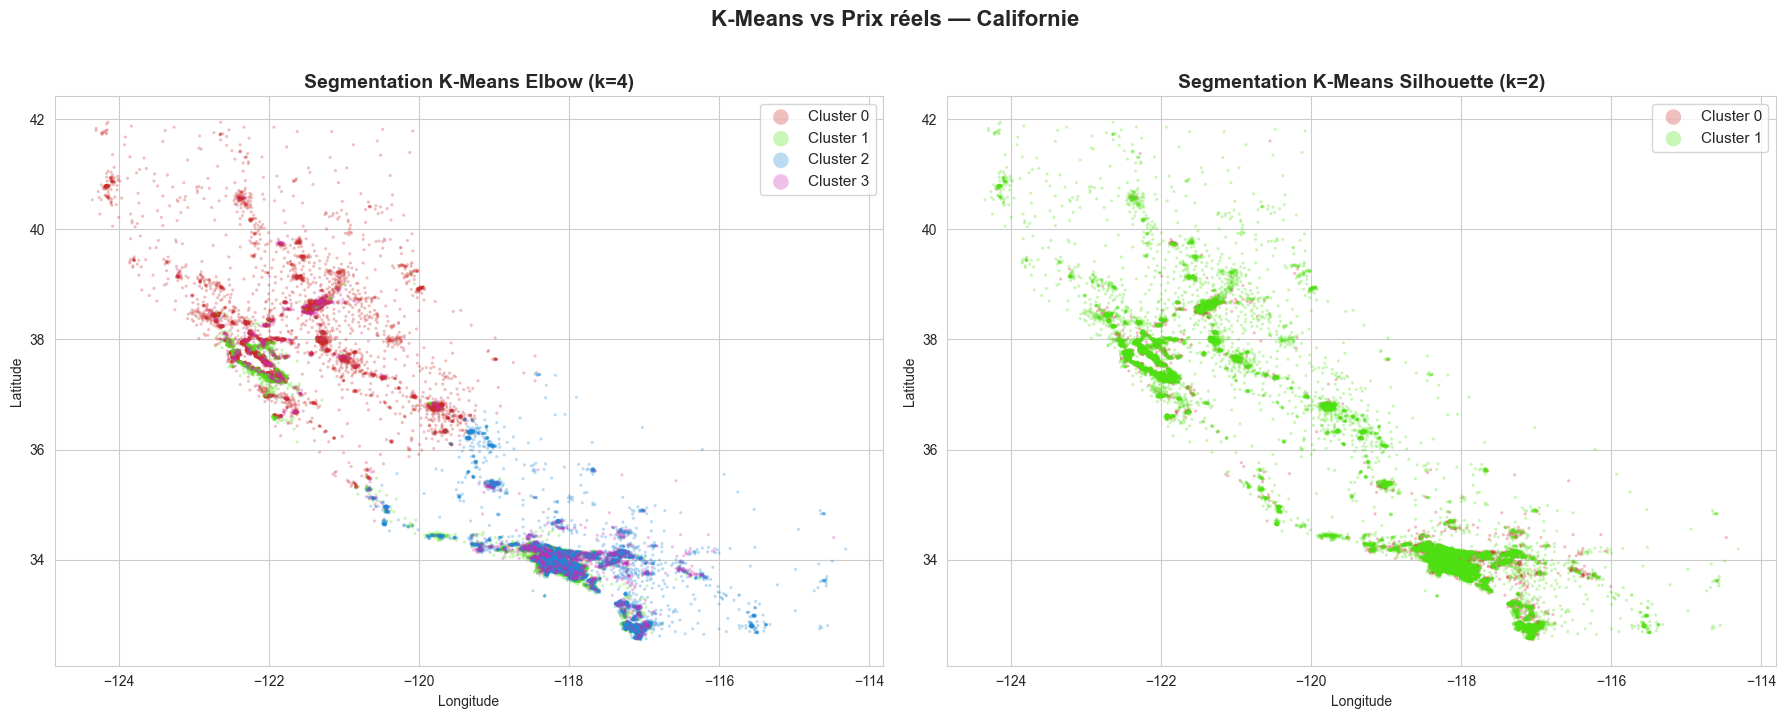

In [13]:
# Carte géographique colorée par cluster
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
available_colors = ['#ca2b2b', '#4ee212', '#1f88d6', '#ca2bb3']

# Clusters Elbow
for cluster_id in range(optimal_k):
    mask = df['cluster_elbow'] == cluster_id
    axes[0].scatter(df.loc[mask, 'longitude'], df.loc[mask, 'latitude'], c=available_colors[cluster_id], alpha=0.3, s=5, label=f'Cluster {cluster_id}', edgecolors='none')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title(f'Segmentation K-Means Elbow (k={optimal_k})', fontsize=14, fontweight='bold')
axes[0].legend(markerscale=5, fontsize=11)

# Clusters Silhouette
for cluster_id in range(best_k):
    mask = df['cluster_silhouette'] == cluster_id
    axes[1].scatter(df.loc[mask, 'longitude'], df.loc[mask, 'latitude'], c=available_colors[cluster_id], alpha=0.3, s=5, label=f'Cluster {cluster_id}', edgecolors='none')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title(f'Segmentation K-Means Silhouette (k={best_k})', fontsize=14, fontweight='bold')
axes[1].legend(markerscale=5, fontsize=11)


plt.suptitle('K-Means vs Prix réels — Californie', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Analyse des clusters

Par soucis de précision, on décide de garder la clusterisation en 4 groupes via la méthode Elbow. Nous allons donc étudier les différentes statistiques relatives aux colonnes de ces clusters.

In [17]:
# Statistiques moyennes par cluster
cols_analyse = ['median_house_value', 'median_income', 'housing_median_age']

# Garder seulement les colonnes existantes
cols_analyse = [c for c in cols_analyse if c in df.columns]

print('=== CARACTÉRISTIQUES MOYENNES PAR CLUSTER (ELBOW) ===')
cluster_stats = df.groupby('cluster_elbow')[cols_analyse].mean().round(2)
print(cluster_stats.T)
print()

print('=== CARACTÉRISTIQUES MOYENNES PAR CLUSTER (SILHOUETTE) ===')
cluster_stats = df.groupby('cluster_silhouette')[cols_analyse].mean().round(2)
print(cluster_stats.T)

=== CARACTÉRISTIQUES MOYENNES PAR CLUSTER (ELBOW) ===
cluster_elbow               0          1          2          3
median_house_value  163909.01  406016.45  171527.74  216186.25
median_income            3.30       6.80       3.28       4.12
housing_median_age      29.49      29.85      29.68      16.39

=== CARACTÉRISTIQUES MOYENNES PAR CLUSTER (SILHOUETTE) ===
cluster_silhouette          0          1
median_house_value  223217.65  204700.91
median_income            4.18       3.83
housing_median_age      17.63      30.09


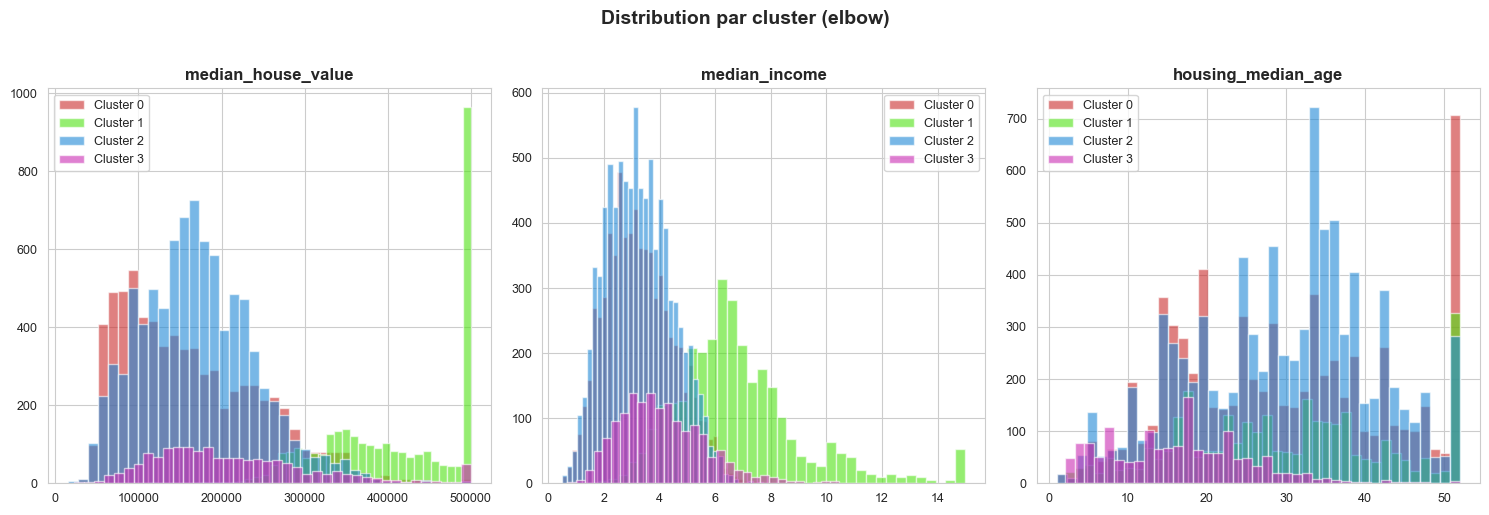

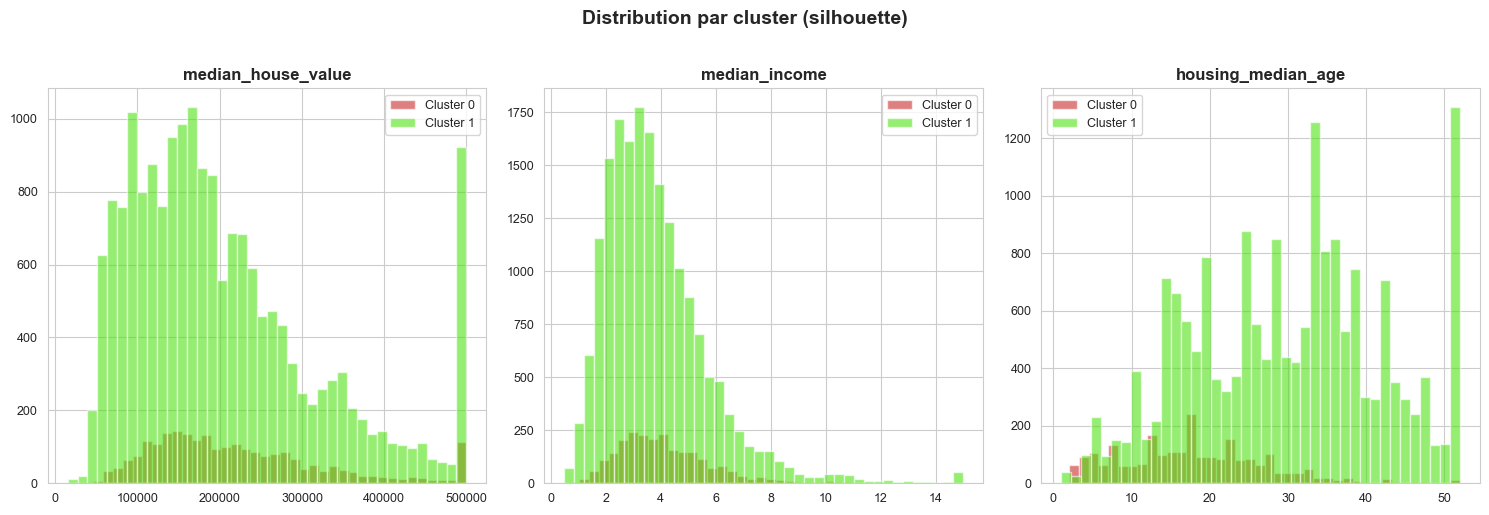

In [18]:
# Comparaison visuelle des clusters
compare_cols = ['median_house_value', 'median_income', 'housing_median_age']
compare_cols = [c for c in compare_cols if c in df.columns]

fig_elbow, axes_elbow = plt.subplots(1, len(compare_cols), figsize=(5 * len(compare_cols), 5))

for i, col in enumerate(compare_cols):
    ax = axes_elbow[i] if len(compare_cols) > 1 else axes_elbow
    for cluster_id in range(optimal_k):
        data = df[df['cluster_elbow'] == cluster_id][col]
        ax.hist(data, bins=40, alpha=0.6, color=available_colors[cluster_id],
                label=f'Cluster {cluster_id}', edgecolor='white')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

plt.suptitle('Distribution par cluster (elbow)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig_silhouette, axes_silhouette = plt.subplots(1, len(compare_cols), figsize=(5 * len(compare_cols), 5))

for i, col in enumerate(compare_cols):
    ax = axes_silhouette[i] if len(compare_cols) > 1 else axes_silhouette
    for cluster_id in range(best_k):
        data = df[df['cluster_silhouette'] == cluster_id][col]
        ax.hist(data, bins=40, alpha=0.6, color=available_colors[cluster_id],
                label=f'Cluster {cluster_id}', edgecolor='white')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

plt.suptitle('Distribution par cluster (silhouette)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()